In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import os

In [2]:
df = pd.read_csv('House_Price.csv')
df.head(1)

,price,resid_area,air_qual,room_num,age,dist1,dist2,dist3,dist4,teachers,poor_prop,airport,n_hos_beds,n_hot_rooms,waterbody,rainfall,bus_ter,parks,Sold
0,24.0,32.31,0.538,6.575,65.2,4.35,3.81,4.18,4.01,24.7,4.98,YES,5.48,11.192,River,23,YES,0.049347,0


In [3]:
df.shape


(506, 19)

In [4]:
df.describe()

,price,resid_area,air_qual,room_num,age,dist1,dist2,dist3,dist4,teachers,poor_prop,n_hos_beds,n_hot_rooms,rainfall,parks,Sold
count,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,498.000000,506.000000,506.000000,506.000000,506.000000
mean,22.528854,41.136779,0.554695,6.284634,68.574901,3.971996,3.628775,3.960672,3.618972,21.544466,12.653063,7.899767,13.041605,39.181818,0.054454,0.454545
std,9.182176,6.860353,0.115878,0.702617,28.148861,2.108532,2.108580,2.119797,2.099203,2.164946,7.141062,1.476683,5.238957,12.513697,0.010632,0.498422
min,5.000000,30.460000,0.385000,3.561000,2.900000,1.130000,0.920000,1.150000,0.730000,18.000000,1.730000,5.268000,10.057600,3.000000,0.033292,0.000000
25%,17.025000,35.190000,0.449000,5.885500,45.025000,2.270000,1.940000,2.232500,1.940000,19.800000,6.950000,6.634500,11.189800,28.000000,0.046464,0.000000
50%,21.200000,39.690000,0.538000,6.208500,77.500000,3.385000,3.010000,3.375000,3.070000,20.950000,11.360000,7.999000,12.720000,39.000000,0.053507,0.000000
75%,25.000000,48.100000,0.624000,6.623500,94.075000,5.367500,4.992500,5.407500,4.985000,22.600000,16.955000,9.088000,14.170800,50.000000,0.061397,1.000000
max,50.000000,57.740000,0.871000,8.780000,100.000000,12.320000,11.930000,12.320000,11.940000,27.400000,37.970000,10.876000,101.120000,60.000000,0.086711,1.000000


In [5]:
df.isnull().sum()

price            0
resid_area       0
air_qual         0
room_num         0
age              0
dist1            0
dist2            0
dist3            0
dist4            0
teachers         0
poor_prop        0
airport          0
n_hos_beds       8
n_hot_rooms      0
waterbody      155
rainfall         0
bus_ter          0
parks            0
Sold             0
dtype: int64

In [6]:
df.fillna(df.mode().iloc[0], inplace=True)

Text(0, 0.5, 'Price')

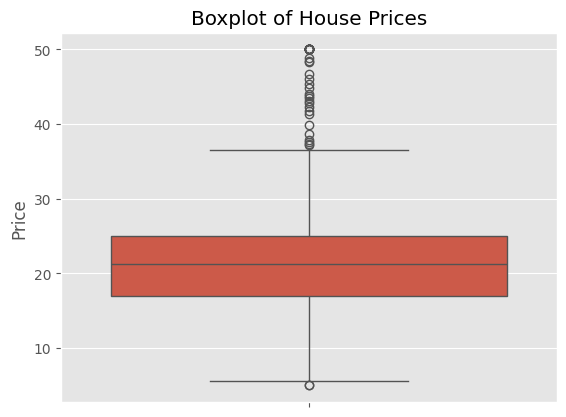

In [27]:
sns.boxplot(y=df['price'])
plt.title('Boxplot of House Prices')
plt.ylabel('Price')

In [8]:
upper = df['price'].quantile(0.99)
df['price'] = np.where(df['price'] > upper, upper, df['price'])

In [9]:
X = df.drop('price', axis=1)
y = df['price']

In [10]:
X = pd.get_dummies(X, drop_first=True)

In [11]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [12]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

In [13]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [14]:
y_pred = model.predict(X_test)

In [15]:
from sklearn.metrics import mean_squared_error, r2_score

mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("RMSE:", rmse)
print("R2 Score:", r2)

# Convert to meaningful text
r2_percent = round(r2 * 100, 2)
rmse_rounded = round(rmse, 2)

print(f"The model explains approximately {r2_percent}% of the variation in house prices, indicating a reasonably strong predictive performance.")
print(f"On average, the model’s predictions deviate from actual prices by about {rmse_rounded} units (based on the dataset’s scale).")

RMSE: 4.653299564070661
R2 Score: 0.7063744814836059
The model explains approximately 70.64% of the variation in house prices, indicating a reasonably strong predictive performance.
On average, the model’s predictions deviate from actual prices by about 4.65 units (based on the dataset’s scale).


In [16]:
coeff_df = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': model.coef_
})

In [17]:
from sklearn.pipeline import Pipeline

pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('model', LinearRegression())
])

pipeline.fit(X_train, y_train)
y_pred = pipeline.predict(X_test)

In [18]:
from sklearn.model_selection import cross_val_score

scores = cross_val_score(pipeline, X_scaled, y, cv=5)
print("CV Mean R2:", scores.mean())

CV Mean R2: 0.519786623500105


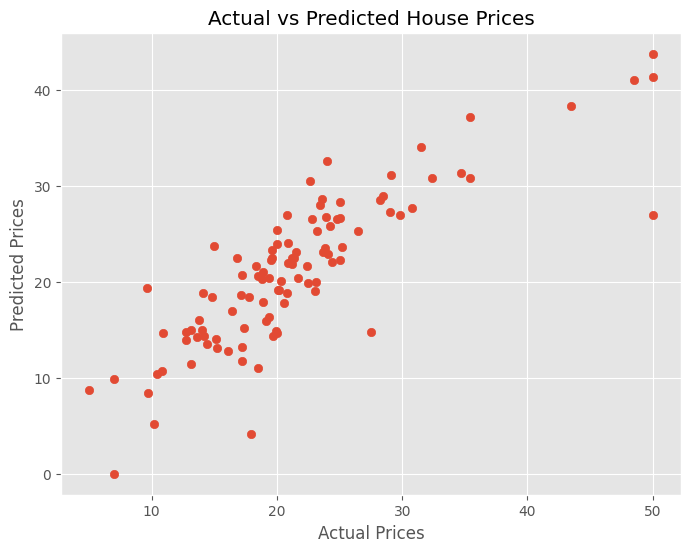

In [19]:
import matplotlib.pyplot as plt

plt.style.use('ggplot')
plt.figure(figsize=(8,6))
plt.scatter(y_test, y_pred)
plt.xlabel("Actual Prices")
plt.ylabel("Predicted Prices")
plt.title("Actual vs Predicted House Prices")
plt.show()

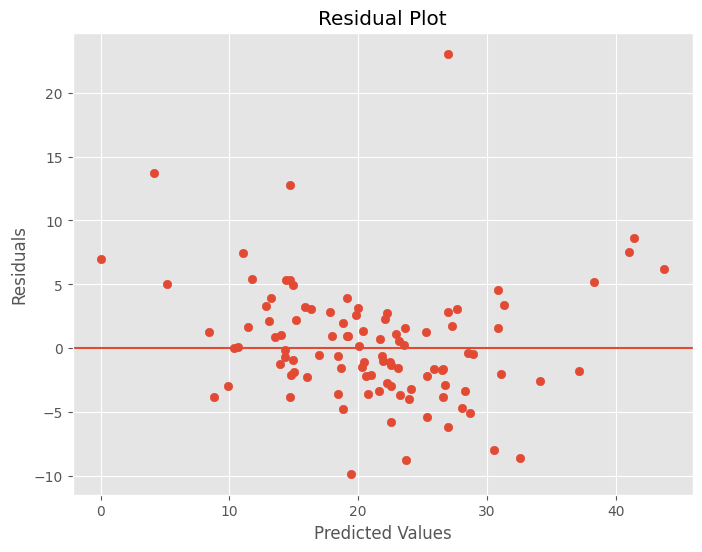

In [20]:
residuals = y_test - y_pred
plt.style.use('ggplot')
plt.figure(figsize=(8,6))
plt.scatter(y_pred, residuals)
plt.xlabel("Predicted Values")
plt.ylabel("Residuals")
plt.title("Residual Plot")
plt.axhline(y=0)
plt.show()

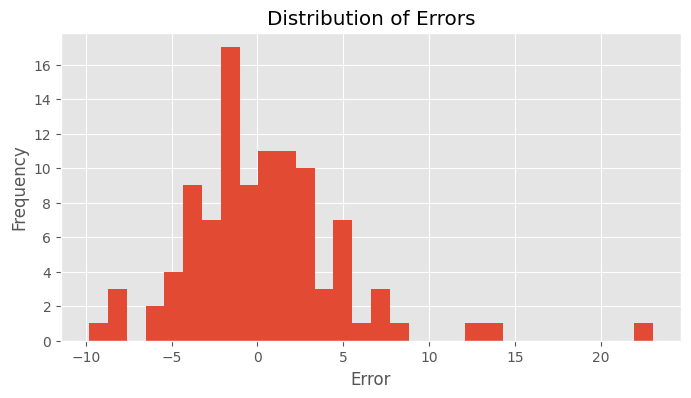

In [21]:
plt.style.use('ggplot')
plt.figure(figsize=(8,4))
plt.hist(residuals, bins=30)
plt.title("Distribution of Errors")
plt.xlabel("Error")
plt.ylabel("Frequency")
plt.show()

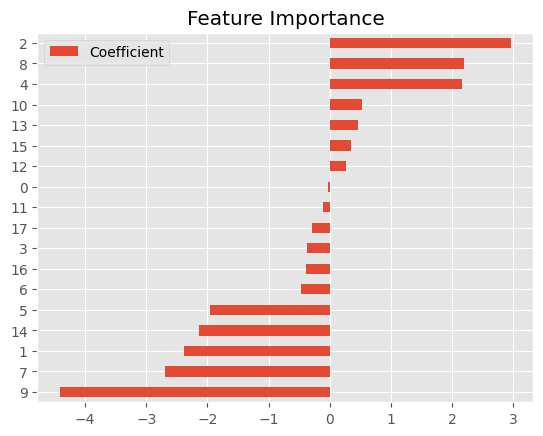

In [22]:
import pandas as pd

coeff_df = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": model.coef_
})

coeff_df.sort_values(by="Coefficient").plot(kind='barh')
plt.title("Feature Importance")
plt.show()

Text(0.5, 1.0, 'Distribution of Residuals')

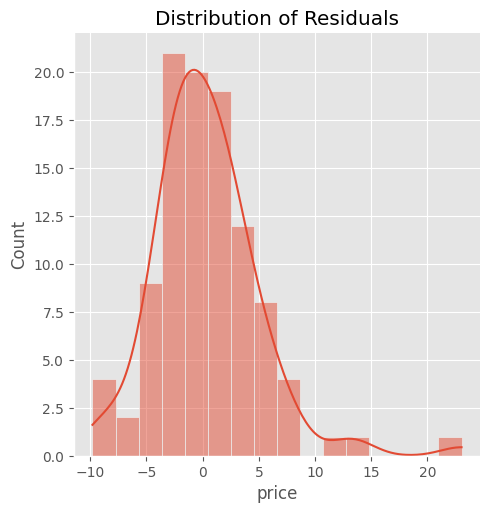

In [23]:
sns.displot(residuals, kde=True)
plt.title("Distribution of Residuals")

In [24]:
iris=sns.load_dataset('iris')
iris.head(1)

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa


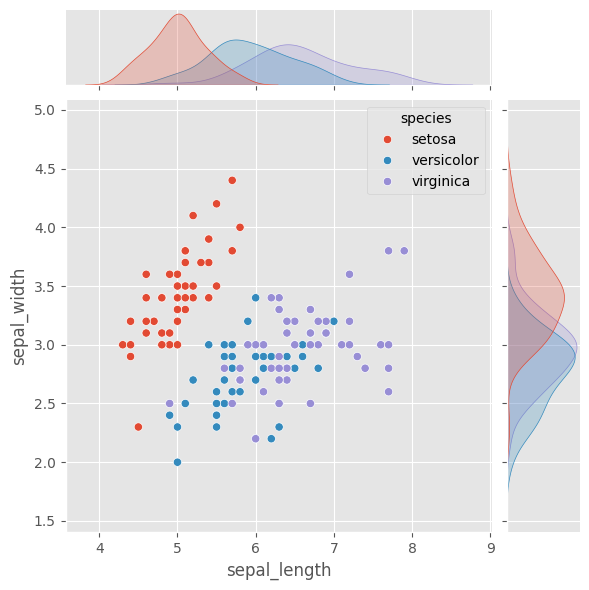

In [25]:
sns.jointplot(x=iris.sepal_length, y=iris.sepal_width, hue=iris.species)

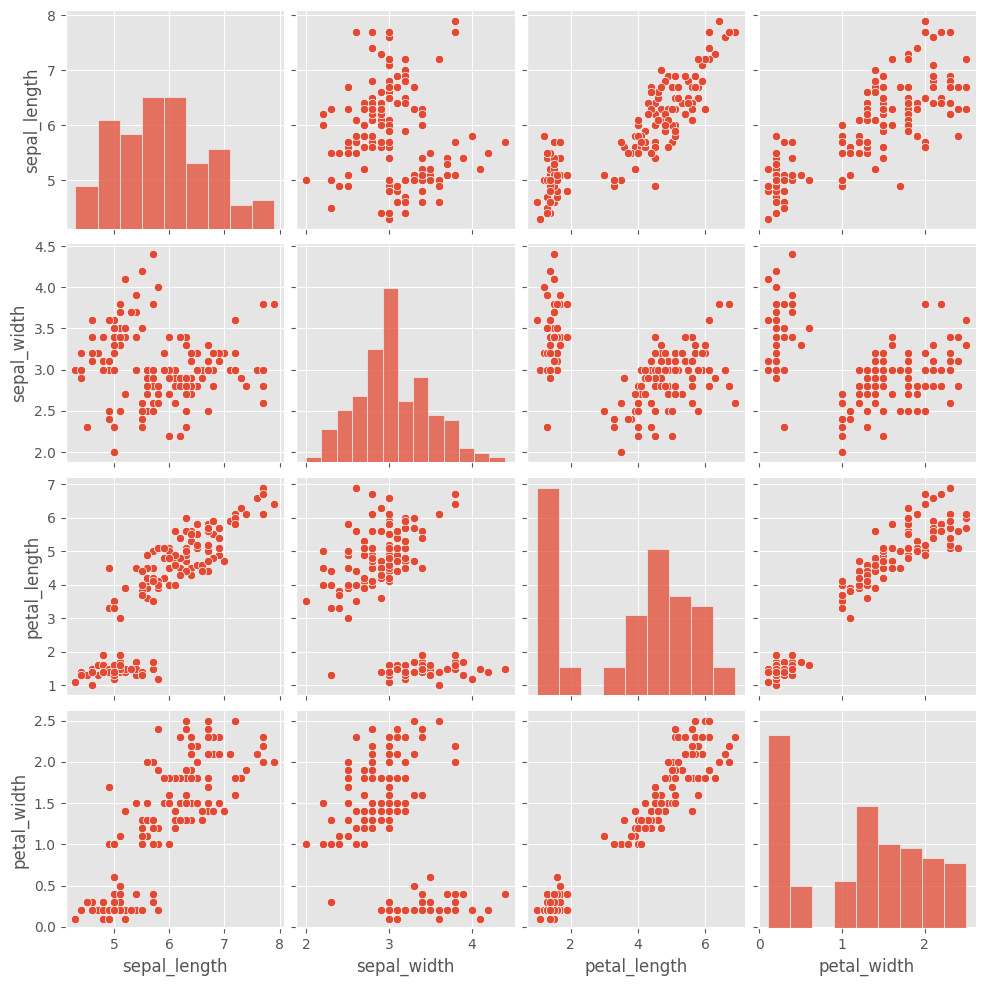

In [26]:
sns.pairplot(iris)